# 🎬 Sistem Rekomendasi Film — KNN Collaborative Filtering
### Integrasi Algoritma K-Nearest Neighbor pada User-Item Collaborative Filtering untuk Sistem Rekomendasi Film Berbasis Web
---
**Dataset:** MovieLens (ml-latest-small)  
**Algoritma:** KNN + Cosine Similarity  
**Output:** Dataset bersih siap pakai untuk aplikasi web

> ⚡ Jalankan setiap cell **secara berurutan** dari atas ke bawah (Shift+Enter)


---
## 📦 STEP 1 — Install Library & Upload Dataset

### 1.1 Install semua library yang dibutuhkan


In [1]:
# Install library (jalankan cell ini pertama kali)
!pip install pandas numpy scikit-learn scipy matplotlib seaborn flask-ngrok pyngrok -q

print("✅ Semua library berhasil diinstall!")


✅ Semua library berhasil diinstall!


### 1.2 Upload file dataset

Klik tombol **Choose Files** yang muncul setelah menjalankan cell ini, lalu pilih file **ml-latest-small.zip** yang sudah kamu download.


In [2]:
from google.colab import files
import zipfile, os

# Upload file zip
print("📂 Silakan upload file ml-latest-small.zip ...")
uploaded = files.upload()

# Ekstrak zip
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset/')

print("\n✅ Dataset berhasil diekstrak!")
print("📁 File yang tersedia:")
for f in os.listdir('/content/dataset/'):
    size = os.path.getsize(f'/content/dataset/{f}')
    print(f"   └─ {f} ({size/1024:.1f} KB)")


📂 Silakan upload file ml-latest-small.zip ...


Saving ml-latest-small.zip to ml-latest-small.zip

✅ Dataset berhasil diekstrak!
📁 File yang tersedia:
   └─ links.csv (3.2 KB)
   └─ movies.csv (9.1 KB)
   └─ tags.csv (8.2 KB)
   └─ ratings.csv (213.3 KB)


---
## 📊 STEP 2 — Load & Eksplorasi Data Awal (EDA)

### 2.1 Load semua file CSV ke dalam DataFrame


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Load dataset ──────────────────────────────────────────────────────────────
ratings = pd.read_csv('/content/dataset/ratings.csv')
movies  = pd.read_csv('/content/dataset/movies.csv')
tags    = pd.read_csv('/content/dataset/tags.csv')
links   = pd.read_csv('/content/dataset/links.csv')

print("=" * 55)
print("      RINGKASAN DATASET MOVIELENS")
print("=" * 55)
print(f"  📊 ratings.csv  : {len(ratings):>7,} baris × {ratings.shape[1]} kolom")
print(f"  🎬 movies.csv   : {len(movies):>7,} baris × {movies.shape[1]} kolom")
print(f"  🏷️  tags.csv     : {len(tags):>7,} baris × {tags.shape[1]} kolom")
print(f"  🔗 links.csv    : {len(links):>7,} baris × {links.shape[1]} kolom")
print("=" * 55)
print(f"  👤 Total pengguna unik : {ratings['userId'].nunique()}")
print(f"  🎥 Total film unik     : {ratings['movieId'].nunique()}")
print(f"  ⭐ Rentang rating      : {ratings['rating'].min()} – {ratings['rating'].max()}")
print("=" * 55)


      RINGKASAN DATASET MOVIELENS
  📊 ratings.csv  :   9,657 baris × 4 kolom
  🎬 movies.csv   :     195 baris × 3 kolom
  🏷️  tags.csv     :     300 baris × 4 kolom
  🔗 links.csv    :     195 baris × 3 kolom
  👤 Total pengguna unik : 610
  🎥 Total film unik     : 219
  ⭐ Rentang rating      : 0.5 – 5.0


### 2.2 Tampilkan sampel data dari setiap file


In [4]:
print("\n📋 5 baris pertama ratings.csv:")
display(ratings.head())

print("\n📋 5 baris pertama movies.csv:")
display(movies.head())

print("\n📋 5 baris pertama tags.csv:")
display(tags.head())



📋 5 baris pertama ratings.csv:


,userId,movieId,rating,timestamp
0,103,628,4.00,1169094780
1,436,390,1.00,1240343885
2,271,497,3.00,1494921984
3,107,527,2.00,1476576418
4,72,269,4.00,1072517628



📋 5 baris pertama movies.csv:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,5,Father of the Bride Part II (1995),Comedy
4,6,Heat (1995),Action|Crime|Thriller



📋 5 baris pertama tags.csv:


,userId,movieId,tag,timestamp
0,113,350,sequel,1275207787
1,174,176,feel-good,1202456944
2,74,593,cult,1517236236
3,536,575,cult,1038616324
4,32,357,sequel,1002267887


### 2.3 Cek tipe data dan missing values


In [5]:
print("=" * 50)
print("  INFORMASI TIPE DATA — ratings.csv")
print("=" * 50)
ratings.info()

print("\n" + "=" * 50)
print("  CEK MISSING VALUES")
print("=" * 50)
for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    mv = df.isnull().sum().sum()
    icon = "✅" if mv == 0 else "⚠️"
    print(f"  {icon} {name}.csv   : {mv} missing values")

print("\n" + "=" * 50)
print("  STATISTIK DESKRIPTIF — RATING")
print("=" * 50)
display(ratings['rating'].describe().to_frame().T)


  INFORMASI TIPE DATA — ratings.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9657 entries, 0 to 9656
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     9657 non-null   int64  
 1   movieId    9657 non-null   int64  
 2   rating     9657 non-null   float64
 3   timestamp  9657 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 301.9 KB

  CEK MISSING VALUES
  ✅ ratings.csv   : 0 missing values
  ✅ movies.csv   : 0 missing values
  ✅ tags.csv   : 0 missing values
  ✅ links.csv   : 0 missing values

  STATISTIK DESKRIPTIF — RATING


,count,mean,std,min,25%,50%,75%,max
rating,9657.00,3.50,0.98,0.50,3.00,3.50,4.00,5.00


### 2.4 Visualisasi distribusi rating dan aktivitas pengguna


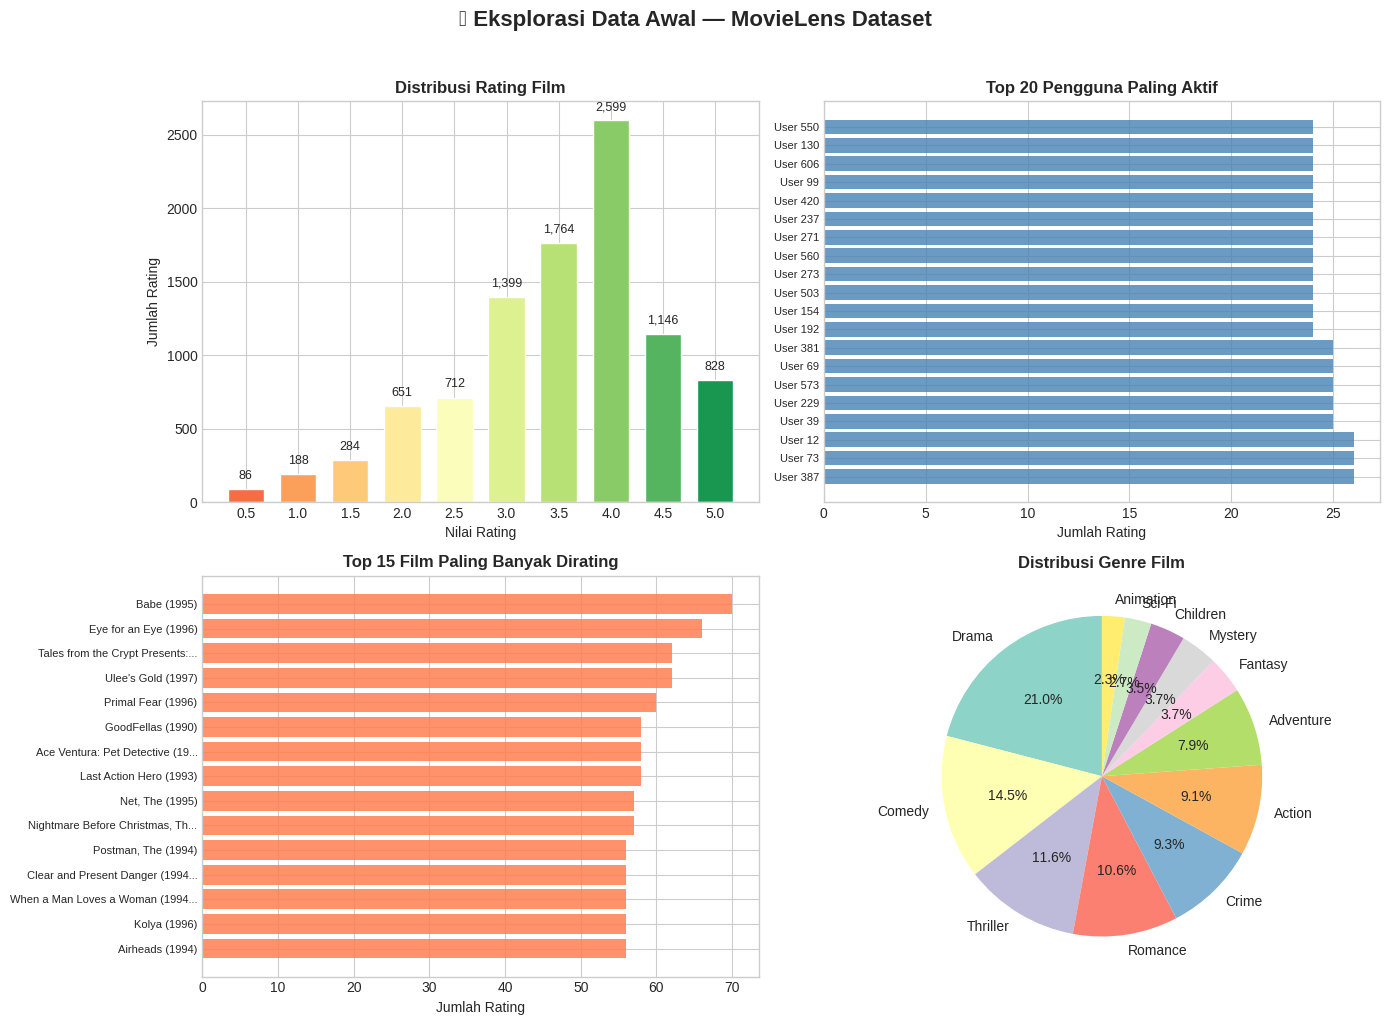

✅ Visualisasi EDA berhasil dibuat!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Eksplorasi Data Awal — MovieLens Dataset', fontsize=16, fontweight='bold', y=1.02)

# 1. Distribusi Rating
ax1 = axes[0, 0]
rating_counts = ratings['rating'].value_counts().sort_index()
bars = ax1.bar(rating_counts.index.astype(str), rating_counts.values,
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(rating_counts))), edgecolor='white', width=0.7)
ax1.set_title('Distribusi Rating Film', fontweight='bold')
ax1.set_xlabel('Nilai Rating')
ax1.set_ylabel('Jumlah Rating')
for bar, val in zip(bars, rating_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# 2. Jumlah Rating per Pengguna (Top 20)
ax2 = axes[0, 1]
user_counts = ratings['userId'].value_counts().head(20)
ax2.barh(range(20), user_counts.values, color='steelblue', alpha=0.8)
ax2.set_yticks(range(20))
ax2.set_yticklabels([f'User {u}' for u in user_counts.index], fontsize=8)
ax2.set_title('Top 20 Pengguna Paling Aktif', fontweight='bold')
ax2.set_xlabel('Jumlah Rating')

# 3. Top 15 Film Terbanyak Dirating
ax3 = axes[1, 0]
top_movies = ratings['movieId'].value_counts().head(15)
top_movie_titles = movies[movies['movieId'].isin(top_movies.index)].set_index('movieId')['title']
labels = [t[:30]+'...' if len(t)>30 else t for t in [top_movie_titles.get(m, f'Film {m}') for m in top_movies.index]]
ax3.barh(range(15), top_movies.values[::-1], color='coral', alpha=0.85)
ax3.set_yticks(range(15))
ax3.set_yticklabels(labels[::-1], fontsize=8)
ax3.set_title('Top 15 Film Paling Banyak Dirating', fontweight='bold')
ax3.set_xlabel('Jumlah Rating')

# 4. Distribusi Genre
ax4 = axes[1, 1]
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(12)
ax4.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
        colors=plt.cm.Set3(np.linspace(0,1,12)), startangle=90)
ax4.set_title('Distribusi Genre Film', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi EDA berhasil dibuat!")


---
## 🔧 STEP 3 — Pra-Pemrosesan Data (Data Preprocessing)

### 3.1 Konversi timestamp ke format tanggal yang terbaca


In [7]:
import datetime

# Konversi timestamp → datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['timestamp']    = pd.to_datetime(tags['timestamp'],    unit='s')

# Ekstrak informasi tambahan dari timestamp
ratings['year_rated']  = ratings['timestamp'].dt.year
ratings['month_rated'] = ratings['timestamp'].dt.month

print("✅ Timestamp berhasil dikonversi!")
print("\n📋 ratings.csv setelah konversi timestamp:")
display(ratings.head(3))


✅ Timestamp berhasil dikonversi!

📋 ratings.csv setelah konversi timestamp:


,userId,movieId,rating,timestamp,year_rated,month_rated
0,103,628,4.00,2007-01-18 04:33:00,2007,1
1,436,390,1.00,2009-04-21 19:58:05,2009,4
2,271,497,3.00,2017-05-16 08:06:24,2017,5


### 3.2 Ekstrak tahun rilis film dari kolom title


In [8]:
import re

def extract_year(title):
    """Ekstrak tahun rilis dari judul film (format: 'Title (YYYY)')"""
    match = re.search(r'\((\d{4})\)', str(title))
    return int(match.group(1)) if match else np.nan

def clean_title(title):
    """Hapus tahun dari judul film"""
    return re.sub(r'\s*\(\d{4}\)\s*$', '', str(title)).strip()

movies['release_year'] = movies['title'].apply(extract_year)
movies['clean_title']  = movies['title'].apply(clean_title)

print("✅ Tahun rilis berhasil diekstrak!")
print(f"   Film dengan tahun    : {movies['release_year'].notna().sum()}")
print(f"   Film tanpa tahun     : {movies['release_year'].isna().sum()}")
print("\n📋 movies.csv setelah ekstraksi tahun:")
display(movies[['movieId','title','clean_title','release_year','genres']].head(8))


✅ Tahun rilis berhasil diekstrak!
   Film dengan tahun    : 194
   Film tanpa tahun     : 1

📋 movies.csv setelah ekstraksi tahun:


,movieId,title,clean_title,release_year,genres
0,1,Toy Story (1995),Toy Story,1995.00,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Jumanji,1995.00,Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Grumpier Old Men,1995.00,Comedy|Romance
3,5,Father of the Bride Part II (1995),Father of the Bride Part II,1995.00,Comedy
4,6,Heat (1995),Heat,1995.00,Action|Crime|Thriller
5,7,Sabrina (1995),Sabrina,1995.00,Comedy|Romance
6,10,GoodFellas (1990),GoodFellas,1990.00,Crime|Drama
7,11,"American President, The (1995)","American President, The",1995.00,Comedy|Drama|Romance


### 3.3 Pecah kolom genres menjadi list dan one-hot encoding


In [9]:
# Ganti '(no genres listed)' dengan NaN
movies['genres'] = movies['genres'].replace('(no genres listed)', np.nan)

# Buat kolom genres_list (list of genres per film)
movies['genres_list'] = movies['genres'].apply(
    lambda x: x.split('|') if pd.notna(x) else []
)

# One-hot encoding untuk setiap genre
all_unique_genres = sorted(set(g for gl in movies['genres_list'] for g in gl))
print(f"📂 Ditemukan {len(all_unique_genres)} genre unik:")
print("   " + " | ".join(all_unique_genres))

for genre in all_unique_genres:
    movies[f'genre_{genre.replace("-","_").replace(" ","_")}'] = movies['genres_list'].apply(
        lambda gl: 1 if genre in gl else 0
    )

genre_cols = [c for c in movies.columns if c.startswith('genre_')]
print(f"\n✅ One-hot encoding selesai: {len(genre_cols)} kolom genre ditambahkan")
display(movies[['movieId','clean_title'] + genre_cols[:6]].head(5))


📂 Ditemukan 19 genre unik:
   Action | Adventure | Animation | Children | Comedy | Crime | Dance | Drama | Fantasy | Film-Noir | Horror | Music | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western

✅ One-hot encoding selesai: 19 kolom genre ditambahkan


,movieId,clean_title,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime
0,1,Toy Story,0,1,1,1,1,0
1,2,Jumanji,0,1,0,1,0,0
2,3,Grumpier Old Men,0,0,0,0,1,0
3,5,Father of the Bride Part II,0,0,0,0,1,0
4,6,Heat,1,0,0,0,0,1


### 3.4 Identifikasi dan tangani duplikat


In [10]:
print("=" * 50)
print("  CEK DUPLIKAT DATA")
print("=" * 50)

# Cek duplikat di ratings (kombinasi userId-movieId harus unik)
dup_ratings = ratings.duplicated(subset=['userId','movieId']).sum()
print(f"  ⚠️  Duplikat di ratings (userId+movieId) : {dup_ratings}")

# Cek duplikat di movies
dup_movies = movies.duplicated(subset=['movieId']).sum()
print(f"  ⚠️  Duplikat di movies (movieId)          : {dup_movies}")

# Hapus duplikat jika ada
if dup_ratings > 0:
    ratings = ratings.drop_duplicates(subset=['userId','movieId'], keep='last')
    print(f"  ✅ {dup_ratings} duplikat rating dihapus")
else:
    print("  ✅ Tidak ada duplikat di ratings")

if dup_movies > 0:
    movies = movies.drop_duplicates(subset=['movieId'], keep='first')
    print(f"  ✅ {dup_movies} duplikat movies dihapus")
else:
    print("  ✅ Tidak ada duplikat di movies")

print(f"\n📊 Shape akhir ratings : {ratings.shape}")
print(f"📊 Shape akhir movies  : {movies.shape}")


  CEK DUPLIKAT DATA
  ⚠️  Duplikat di ratings (userId+movieId) : 0
  ⚠️  Duplikat di movies (movieId)          : 0
  ✅ Tidak ada duplikat di ratings
  ✅ Tidak ada duplikat di movies

📊 Shape akhir ratings : (9657, 6)
📊 Shape akhir movies  : (195, 25)


### 3.5 Filtering pengguna aktif & film populer (kurangi sparsity)


In [11]:
print("SEBELUM FILTERING")
print(f"  Pengguna : {ratings['userId'].nunique()}")
print(f"  Film     : {ratings['movieId'].nunique()}")
print(f"  Rating   : {len(ratings):,}")

n_users_b4  = ratings['userId'].nunique()
n_movies_b4 = ratings['movieId'].nunique()
sparsity_b4 = 1 - (len(ratings) / (n_users_b4 * n_movies_b4))
print(f"  Sparsity : {sparsity_b4:.2%}")

# ── Filter: pengguna min. 5 rating, film min. 3 rating ────────────────────────
MIN_USER_RATINGS  = 5   # Pengguna harus memberi minimal 5 rating
MIN_MOVIE_RATINGS = 3   # Film harus mendapat minimal 3 rating

for iteration in range(3):  # Iterasi untuk konvergensi
    user_counts  = ratings['userId'].value_counts()
    movie_counts = ratings['movieId'].value_counts()
    active_users   = user_counts[user_counts  >= MIN_USER_RATINGS].index
    popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
    ratings = ratings[ratings['userId'].isin(active_users) &
                      ratings['movieId'].isin(popular_movies)]

print("\nSESUDAH FILTERING")
print(f"  Pengguna : {ratings['userId'].nunique()}")
print(f"  Film     : {ratings['movieId'].nunique()}")
print(f"  Rating   : {len(ratings):,}")

n_users_af  = ratings['userId'].nunique()
n_movies_af = ratings['movieId'].nunique()
sparsity_af = 1 - (len(ratings) / (n_users_af * n_movies_af))
print(f"  Sparsity : {sparsity_af:.2%}")
print(f"\n✅ Sparsity berkurang dari {sparsity_b4:.2%} → {sparsity_af:.2%}")


SEBELUM FILTERING
  Pengguna : 610
  Film     : 219
  Rating   : 9,657
  Sparsity : 92.77%

SESUDAH FILTERING
  Pengguna : 610
  Film     : 219
  Rating   : 9,657
  Sparsity : 92.77%

✅ Sparsity berkurang dari 92.77% → 92.77%


### 3.6 Normalisasi rating (Mean-Centering per pengguna)


In [12]:
# Hitung statistik rating per pengguna
user_stats = ratings.groupby('userId')['rating'].agg(['mean','std','count']).reset_index()
user_stats.columns = ['userId','rating_mean','rating_std','rating_count']
user_stats['rating_std'] = user_stats['rating_std'].fillna(0)

# Gabungkan ke ratings
ratings = ratings.merge(user_stats, on='userId', how='left')

# Mean-centering: rating_normalized = rating - mean_user
ratings['rating_normalized'] = ratings['rating'] - ratings['rating_mean']

print("✅ Normalisasi rating (mean-centering) selesai!")
print("\n📋 Contoh hasil normalisasi:")
display(ratings[['userId','movieId','rating','rating_mean','rating_normalized']].head(10))

print(f"\n📊 Statistik rating_normalized:")
display(ratings['rating_normalized'].describe().to_frame().T)


✅ Normalisasi rating (mean-centering) selesai!

📋 Contoh hasil normalisasi:


,userId,movieId,rating,rating_mean,rating_normalized
0,103,628,4.00,3.62,0.38
1,436,390,1.00,3.09,-2.09
2,271,497,3.00,3.42,-0.42
3,107,527,2.00,3.33,-1.33
4,72,269,4.00,3.62,0.38
5,21,216,4.00,3.42,0.58
6,122,47,4.50,3.74,0.76
7,467,36,0.50,3.31,-2.81
8,215,25,3.50,3.32,0.18
9,331,568,4.00,3.92,0.08



📊 Statistik rating_normalized:


,count,mean,std,min,25%,50%,75%,max
rating_normalized,9657.00,0.00,0.95,-3.23,-0.56,0.16,0.65,2.38


---
## 🧹 STEP 4 — Integrasi & Pembersihan Data Final

### 4.1 Gabungkan ratings dengan informasi film


In [13]:
# Merge ratings dengan movies
ratings_movies = ratings.merge(
    movies[['movieId','clean_title','genres','genres_list','release_year'] + genre_cols],
    on='movieId',
    how='left'
)

print(f"✅ Merge berhasil!")
print(f"   Shape ratings_movies : {ratings_movies.shape}")
print("\n📋 5 baris pertama dataset gabungan:")
display(ratings_movies[['userId','movieId','clean_title','rating','rating_normalized',
                          'genres','release_year','year_rated']].head())


✅ Merge berhasil!
   Shape ratings_movies : (9657, 33)

📋 5 baris pertama dataset gabungan:


,userId,movieId,clean_title,rating,rating_normalized,genres,release_year,year_rated
0,103,628,Primal Fear,4.00,0.38,Crime|Drama|Mystery|Thriller,1996.00,2007
1,436,390,Three Colors: Red,1.00,-2.09,Drama|Mystery|Romance,1994.00,2009
2,271,497,"Ref, The",3.00,-0.42,Comedy|Crime|Thriller,1994.00,2017
3,107,527,Schindler's List,2.00,-1.33,Drama|War,1993.00,2016
4,72,269,NaN,4.00,0.38,NaN,NaN,2003


### 4.2 Gabungkan dengan informasi tags


In [14]:
# Agregasi tags per film (gabungkan semua tag menjadi satu string)
tags_agg = tags.groupby('movieId')['tag'].apply(
    lambda x: '|'.join(sorted(set(x.str.lower())))
).reset_index()
tags_agg.columns = ['movieId', 'tags_combined']

# Hitung jumlah tag per film
tags_count = tags.groupby('movieId')['tag'].count().reset_index()
tags_count.columns = ['movieId', 'tag_count']

# Merge ke dataset utama
ratings_movies = ratings_movies.merge(tags_agg,   on='movieId', how='left')
ratings_movies = ratings_movies.merge(tags_count,  on='movieId', how='left')
ratings_movies['tags_combined'] = ratings_movies['tags_combined'].fillna('')
ratings_movies['tag_count']     = ratings_movies['tag_count'].fillna(0).astype(int)

print("✅ Tags berhasil digabungkan!")
print(f"   Film dengan tags : {(ratings_movies['tags_combined'] != '').sum():,} records")
print(f"   Film tanpa tags  : {(ratings_movies['tags_combined'] == '').sum():,} records")


✅ Tags berhasil digabungkan!
   Film dengan tags : 6,879 records
   Film tanpa tags  : 2,778 records


### 4.3 Hitung fitur statistik film (untuk web app)


In [15]:
# Hitung statistik per film dari data yang sudah difilter
movie_stats = ratings.groupby('movieId').agg(
    avg_rating   = ('rating', 'mean'),
    num_ratings  = ('rating', 'count'),
    rating_std   = ('rating', 'std'),
    min_rating   = ('rating', 'min'),
    max_rating   = ('rating', 'max')
).reset_index()

movie_stats['avg_rating']  = movie_stats['avg_rating'].round(2)
movie_stats['rating_std']  = movie_stats['rating_std'].fillna(0).round(2)

# Hitung popularity score (kombinasi jumlah rating & rata-rata rating)
movie_stats['popularity_score'] = (
    (movie_stats['num_ratings'] / movie_stats['num_ratings'].max()) * 0.4 +
    (movie_stats['avg_rating']  / 5.0) * 0.6
).round(4)

# Gabungkan ke movies
movies_clean = movies[['movieId','clean_title','title','genres','genres_list','release_year']
                        + genre_cols].merge(movie_stats, on='movieId', how='inner')

print("✅ Statistik film berhasil dihitung!")
print(f"   Total film dalam dataset bersih: {len(movies_clean)}")
print("\n📋 Top 10 film berdasarkan popularity score:")
display(movies_clean.nlargest(10,'popularity_score')[
    ['clean_title','genres','avg_rating','num_ratings','popularity_score']])


✅ Statistik film berhasil dihitung!
   Total film dalam dataset bersih: 195

📋 Top 10 film berdasarkan popularity score:


,clean_title,genres,avg_rating,num_ratings,popularity_score
14,Babe,Children|Drama,3.51,70,0.82
148,Eye for an Eye,Drama|Thriller,3.45,66,0.79
104,Ulee's Gold,Drama,3.52,62,0.78
71,Primal Fear,Crime|Drama|Mystery|Thriller,3.59,60,0.77
49,Kolya,Comedy|Drama|War,3.78,56,0.77
51,Star Wars: Episode IV - A New Hope,Action|Adventure|Sci-Fi,3.84,54,0.77
119,"Nightmare Before Christmas, The",Animation|Children|Fantasy|Musical,3.64,57,0.76
30,Batman Forever,Action|Adventure|Comedy|Crime,3.78,54,0.76
47,Ace Ventura: Pet Detective,Comedy,3.56,58,0.76
59,Clear and Present Danger,Action|Crime|Drama|Thriller,3.62,56,0.75


### 4.4 Validasi kualitas data final


In [16]:
print("=" * 60)
print("         LAPORAN KUALITAS DATA FINAL")
print("=" * 60)

datasets = {
    'ratings_movies'  : ratings_movies,
    'movies_clean'    : movies_clean,
    'user_stats'      : user_stats,
    'movie_stats'     : movie_stats
}

for name, df in datasets.items():
    mv = df.isnull().sum()
    mv_cols = mv[mv > 0]
    print(f"\n📊 {name}:")
    print(f"   Shape        : {df.shape}")
    print(f"   Missing vals : {mv.sum()} total", end="")
    if len(mv_cols) > 0:
        print(f" → di kolom: {dict(mv_cols)}")
    else:
        print(" ✅")

print("\n" + "=" * 60)
print("  RINGKASAN DATASET BERSIH")
print("=" * 60)
print(f"  👤 Pengguna aktif   : {ratings_movies['userId'].nunique()}")
print(f"  🎬 Film valid       : {movies_clean['movieId'].nunique()}")
print(f"  ⭐ Total rating     : {len(ratings_movies):,}")
print(f"  📂 Genre unik       : {len(all_unique_genres)}")
print(f"  ⭐ Rata-rata rating : {ratings_movies['rating'].mean():.2f}")
print("=" * 60)


         LAPORAN KUALITAS DATA FINAL

📊 ratings_movies:
   Shape        : (9657, 35)
   Missing vals : 22980 total → di kolom: {'clean_title': np.int64(996), 'genres': np.int64(1032), 'genres_list': np.int64(996), 'release_year': np.int64(1032), 'genre_Action': np.int64(996), 'genre_Adventure': np.int64(996), 'genre_Animation': np.int64(996), 'genre_Children': np.int64(996), 'genre_Comedy': np.int64(996), 'genre_Crime': np.int64(996), 'genre_Dance': np.int64(996), 'genre_Drama': np.int64(996), 'genre_Fantasy': np.int64(996), 'genre_Film_Noir': np.int64(996), 'genre_Horror': np.int64(996), 'genre_Music': np.int64(996), 'genre_Musical': np.int64(996), 'genre_Mystery': np.int64(996), 'genre_Romance': np.int64(996), 'genre_Sci_Fi': np.int64(996), 'genre_Thriller': np.int64(996), 'genre_War': np.int64(996), 'genre_Western': np.int64(996)}

📊 movies_clean:
   Shape        : (195, 31)
   Missing vals : 2 total → di kolom: {'genres': np.int64(1), 'release_year': np.int64(1)}

📊 user_stats:
   

---
## 🏗️ STEP 5 — Konstruksi Matriks User-Item

### 5.1 Buat pivot table (matriks user-item)


In [17]:
from scipy.sparse import csr_matrix

# Pivot table: baris=userId, kolom=movieId, nilai=rating ternormalisasi
user_item_matrix = ratings_movies.pivot_table(
    index   = 'userId',
    columns = 'movieId',
    values  = 'rating_normalized',
    aggfunc = 'mean'
).fillna(0)

# Konversi ke sparse matrix untuk efisiensi memori
sparse_matrix = csr_matrix(user_item_matrix.values)

print(f"✅ Matriks User-Item berhasil dibuat!")
print(f"   Dimensi : {user_item_matrix.shape[0]} pengguna × {user_item_matrix.shape[1]} film")
print(f"   Tipe    : scipy sparse matrix (CSR)")
print(f"   Non-zero: {sparse_matrix.nnz:,} elemen")
print(f"   Memori  : {sparse_matrix.data.nbytes / 1024:.1f} KB (sparse) vs "
      f"{user_item_matrix.values.nbytes / 1024:.1f} KB (dense)")

# Preview
print("\n📋 Preview matriks (5x5):")
preview_df = pd.DataFrame(
    user_item_matrix.values[:5, :5],
    index=user_item_matrix.index[:5],
    columns=user_item_matrix.columns[:5]
).round(2)
display(preview_df)


✅ Matriks User-Item berhasil dibuat!
   Dimensi : 610 pengguna × 219 film
   Tipe    : scipy sparse matrix (CSR)
   Non-zero: 9,537 elemen
   Memori  : 74.5 KB (sparse) vs 1043.7 KB (dense)

📋 Preview matriks (5x5):


movieId,1,2,3,5,6
userId,,,,,
1,0.00,0.00,0.00,0.00,0.00
2,-0.40,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.00,0.00,0.00


### 5.2 Training Model KNN


In [18]:
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import cross_val_score
import time

# Tentukan K optimal (dari cross-validation sederhana)
K_OPTIMAL = 10  # Bisa disesuaikan berdasarkan evaluasi

print(f"🔧 Training KNN model dengan K={K_OPTIMAL}...")
start = time.time()

knn_model = NearestNeighbors(
    n_neighbors = K_OPTIMAL + 1,  # +1 karena termasuk diri sendiri
    metric      = 'cosine',
    algorithm   = 'brute',        # Harus brute untuk sparse matrix
    n_jobs      = -1
)
knn_model.fit(sparse_matrix)

elapsed = time.time() - start
print(f"✅ Model berhasil ditraining dalam {elapsed:.2f} detik!")
print(f"   Algoritma : {knn_model.algorithm}")
print(f"   Metrik    : {knn_model.metric}")
print(f"   K         : {K_OPTIMAL}")


🔧 Training KNN model dengan K=10...
✅ Model berhasil ditraining dalam 0.00 detik!
   Algoritma : brute
   Metrik    : cosine
   K         : 10


### 5.3 Test fungsi rekomendasi


In [19]:
def get_recommendations(user_id, n_rec=10):
    """
    Menghasilkan Top-N rekomendasi film untuk user_id
    menggunakan User-Based KNN Collaborative Filtering.
    """
    if user_id not in user_item_matrix.index:
        return pd.DataFrame(columns=['movieId','clean_title','genres','predicted_rating'])

    # Ambil vektor user
    idx    = user_item_matrix.index.get_loc(user_id)
    vector = sparse_matrix[idx]

    # Cari K nearest neighbors
    dists, idxs = knn_model.kneighbors(vector, n_neighbors=K_OPTIMAL+1)
    dists = dists.flatten()[1:]   # Hapus diri sendiri
    idxs  = idxs.flatten()[1:]
    sims  = 1 - dists             # Cosine distance → similarity

    # Film yang sudah ditonton
    watched = set(ratings_movies[ratings_movies['userId']==user_id]['movieId'])

    # Prediksi rating menggunakan weighted average
    neighbor_matrix = user_item_matrix.iloc[idxs]
    predicted = {}
    for movie_id in user_item_matrix.columns:
        if movie_id in watched:
            continue
        nr = neighbor_matrix[movie_id]
        nz = nr[nr != 0]
        if len(nz) == 0:
            continue
        sim_nz = sims[[i for i,u in enumerate(neighbor_matrix.index) if u in nz.index]]
        if sim_nz.sum() == 0:
            continue
        predicted[movie_id] = np.dot(sim_nz, nz.values) / sim_nz.sum()

    # Ambil Top-N
    top = sorted(predicted.items(), key=lambda x: x[1], reverse=True)[:n_rec]
    results = []
    for mid, pred in top:
        row = movies_clean[movies_clean['movieId']==mid]
        if len(row) == 0: continue
        results.append({
            'movieId'          : mid,
            'clean_title'      : row['clean_title'].values[0],
            'genres'           : row['genres'].values[0],
            'avg_rating'       : row['avg_rating'].values[0],
            'num_ratings'      : row['num_ratings'].values[0],
            'predicted_rating' : round(pred + user_stats[user_stats['userId']==user_id]['rating_mean'].values[0], 2)
        })
    return pd.DataFrame(results)

# ── TEST: Rekomendasi untuk user pertama ──────────────────────────────────────
sample_user = user_item_matrix.index[0]
recs = get_recommendations(sample_user, n_rec=10)

print(f"🎬 Top-10 Rekomendasi untuk User ID = {sample_user}")
print("=" * 75)
display(recs)


🎬 Top-10 Rekomendasi untuk User ID = 1


,movieId,clean_title,genres,avg_rating,num_ratings,predicted_rating
0,457,Schindler's List,Drama|War,3.55,46,4.77
1,551,"Nightmare Before Christmas, The",Animation|Children|Fantasy|Musical,3.64,57,4.48
2,74,Boy's Life (Enfance nue),Drama,3.55,42,4.48
3,25,Leaving Las Vegas,Drama|Romance,3.43,38,4.46
4,673,Space Jam,Adventure|Animation|Children|Comedy|Fantasy,3.29,40,4.35
5,3,Grumpier Old Men,Comedy|Romance,3.59,50,4.28
6,681,GoodFellas,Crime|Drama,3.63,47,4.27
7,296,Pulp Fiction,Crime|Drama|Thriller,3.36,43,4.14
8,223,Clerks,Comedy,3.33,49,4.12


---
## 💾 STEP 6 — Simpan Dataset Bersih untuk Web App

### 6.1 Buat folder output dan simpan semua file


In [20]:
import os, json, pickle
os.makedirs('/content/clean_dataset', exist_ok=True)

# ── 1. ratings_clean.csv ─────────────────────────────────────────────────────
cols_rating = ['userId','movieId','rating','rating_normalized',
               'rating_mean','rating_count','year_rated','month_rated']
ratings_export = ratings_movies[cols_rating].drop_duplicates()
ratings_export.to_csv('/content/clean_dataset/ratings_clean.csv', index=False)
print(f"✅ ratings_clean.csv     : {len(ratings_export):,} baris")

# ── 2. movies_clean.csv ──────────────────────────────────────────────────────
cols_movie = ['movieId','clean_title','title','genres','release_year',
              'avg_rating','num_ratings','popularity_score'] + genre_cols
movies_export = movies_clean[cols_movie].copy()
movies_export.to_csv('/content/clean_dataset/movies_clean.csv', index=False)
print(f"✅ movies_clean.csv      : {len(movies_export):,} baris")

# ── 3. user_stats.csv ────────────────────────────────────────────────────────
user_stats.to_csv('/content/clean_dataset/user_stats.csv', index=False)
print(f"✅ user_stats.csv        : {len(user_stats):,} baris")

# ── 4. movie_stats.csv ───────────────────────────────────────────────────────
movie_stats.to_csv('/content/clean_dataset/movie_stats.csv', index=False)
print(f"✅ movie_stats.csv       : {len(movie_stats):,} baris")

# ── 5. user_item_matrix.csv (untuk web app) ───────────────────────────────────
user_item_matrix.to_csv('/content/clean_dataset/user_item_matrix.csv')
print(f"✅ user_item_matrix.csv  : {user_item_matrix.shape[0]}×{user_item_matrix.shape[1]}")

# ── 6. Simpan model KNN (pickle) ──────────────────────────────────────────────
model_data = {
    'knn_model'        : knn_model,
    'user_item_matrix' : user_item_matrix,
    'sparse_matrix'    : sparse_matrix,
    'user_stats'       : user_stats,
    'movies_clean'     : movies_clean,
    'K'                : K_OPTIMAL
}
with open('/content/clean_dataset/knn_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print(f"✅ knn_model.pkl         : model KNN tersimpan")

# ── 7. Simpan metadata JSON (untuk web app) ────────────────────────────────────
metadata = {
    'total_users'   : int(ratings_export['userId'].nunique()),
    'total_movies'  : int(movies_export['movieId'].nunique()),
    'total_ratings' : int(len(ratings_export)),
    'genres'        : all_unique_genres,
    'rating_min'    : float(ratings_export['rating'].min()),
    'rating_max'    : float(ratings_export['rating'].max()),
    'rating_mean'   : float(ratings_export['rating'].mean().round(2)),
    'K_optimal'     : K_OPTIMAL,
    'sparsity'      : float(round(sparsity_af, 4)),
}
with open('/content/clean_dataset/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ metadata.json         : metadata sistem")

print("\n" + "=" * 50)
print("  Semua file dataset bersih tersimpan!")
print("  Folder: /content/clean_dataset/")
print("=" * 50)


✅ ratings_clean.csv     : 9,657 baris
✅ movies_clean.csv      : 195 baris
✅ user_stats.csv        : 610 baris
✅ movie_stats.csv       : 219 baris
✅ user_item_matrix.csv  : 610×219
✅ knn_model.pkl         : model KNN tersimpan
✅ metadata.json         : metadata sistem

  Semua file dataset bersih tersimpan!
  Folder: /content/clean_dataset/


### 6.2 Verifikasi semua file output


In [21]:
print("📁 Isi folder /content/clean_dataset/")
print("=" * 55)
total_size = 0
for f in sorted(os.listdir('/content/clean_dataset/')):
    fp   = f'/content/clean_dataset/{f}'
    size = os.path.getsize(fp)
    total_size += size
    icon = '📊' if f.endswith('.csv') else ('🤖' if f.endswith('.pkl') else '📄')
    print(f"  {icon} {f:<35} {size/1024:>8.1f} KB")
print(f"{'─'*55}")
print(f"  📦 Total ukuran: {total_size/1024:.1f} KB ({total_size/1024/1024:.2f} MB)")


📁 Isi folder /content/clean_dataset/
  🤖 knn_model.pkl                         1357.7 KB
  📄 metadata.json                            0.5 KB
  📊 movie_stats.csv                          6.8 KB
  📊 movies_clean.csv                        24.1 KB
  📊 ratings_clean.csv                      497.9 KB
  📊 user_item_matrix.csv                   643.4 KB
  📊 user_stats.csv                          23.7 KB
───────────────────────────────────────────────────────
  📦 Total ukuran: 2554.0 KB (2.49 MB)


### 6.3 Download semua file bersih sebagai ZIP


In [22]:
import shutil

# Buat ZIP dari folder clean_dataset
shutil.make_archive('/content/clean_dataset_KNN', 'zip', '/content/clean_dataset')

size_zip = os.path.getsize('/content/clean_dataset_KNN.zip')
print(f"📦 ZIP berhasil dibuat: clean_dataset_KNN.zip ({size_zip/1024:.1f} KB)")
print("⬇️  Memulai download otomatis...")

# Download ke komputer lokal
files.download('/content/clean_dataset_KNN.zip')
print("✅ Download selesai!")


📦 ZIP berhasil dibuat: clean_dataset_KNN.zip (294.4 KB)
⬇️  Memulai download otomatis...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!


---
## 📈 STEP 7 — Visualisasi Hasil & Ringkasan Final


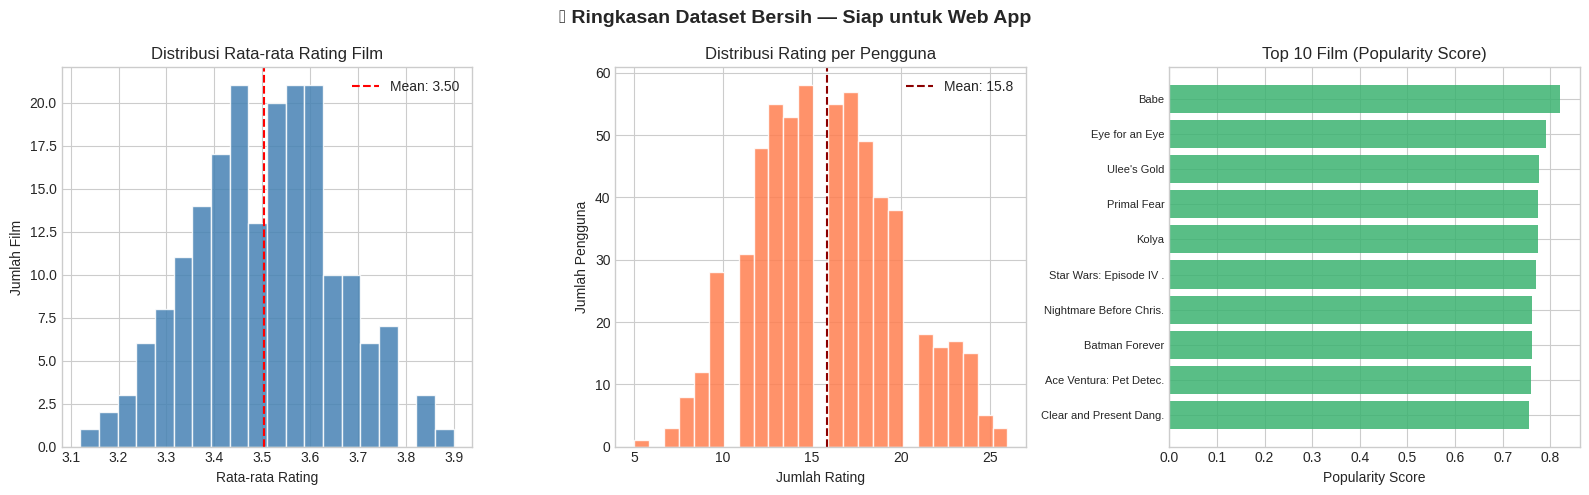


🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 🎉 

✅  PIPELINE PREPROCESSING SELESAI!

       RINGKASAN DATASET BERSIH SIAP WEB APP
  total_users         : 610
  total_movies        : 195
  total_ratings       : 9657
  rating_min          : 0.5
  rating_max          : 5.0
  rating_mean         : 3.5
  K_optimal           : 10
  sparsity            : 0.9277
  genres              : 19 genre → Action, Adventure, Animation, Children, Comedy...

📁 File yang siap digunakan di web app:
   ├── ratings_clean.csv    → data rating bersih
   ├── movies_clean.csv     → info film + genre + statistik
   ├── user_item_matrix.csv → matriks user-item
   ├── knn_model.pkl        → model KNN terlatih
   ├── user_stats.csv       → statistik per pengguna
   ├── movie_stats.csv      → statistik per film
   └── metadata.json        → metadata sistem


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Ringkasan Dataset Bersih — Siap untuk Web App', fontsize=14, fontweight='bold')

# 1. Distribusi avg_rating per film
ax1 = axes[0]
ax1.hist(movies_clean['avg_rating'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(movies_clean['avg_rating'].mean(), color='red', linestyle='--', label=f"Mean: {movies_clean['avg_rating'].mean():.2f}")
ax1.set_title('Distribusi Rata-rata Rating Film')
ax1.set_xlabel('Rata-rata Rating')
ax1.set_ylabel('Jumlah Film')
ax1.legend()

# 2. Distribusi jumlah rating per pengguna
ax2 = axes[1]
user_rating_counts = ratings_export.groupby('userId')['rating'].count()
ax2.hist(user_rating_counts, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(user_rating_counts.mean(), color='darkred', linestyle='--', label=f"Mean: {user_rating_counts.mean():.1f}")
ax2.set_title('Distribusi Rating per Pengguna')
ax2.set_xlabel('Jumlah Rating')
ax2.set_ylabel('Jumlah Pengguna')
ax2.legend()

# 3. Top 10 Film by Popularity Score
ax3 = axes[2]
top10 = movies_clean.nlargest(10, 'popularity_score')
labels = [t[:22]+'.' if len(t)>22 else t for t in top10['clean_title']]
bars = ax3.barh(range(10), top10['popularity_score'].values[::-1], color='mediumseagreen', alpha=0.85)
ax3.set_yticks(range(10))
ax3.set_yticklabels(labels[::-1], fontsize=8)
ax3.set_title('Top 10 Film (Popularity Score)')
ax3.set_xlabel('Popularity Score')

plt.tight_layout()
plt.savefig('/content/clean_dataset/summary_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cetak ringkasan akhir ──────────────────────────────────────────────────────
print("\n" + "🎉 " * 15)
print("\n✅  PIPELINE PREPROCESSING SELESAI!")
print("\n" + "=" * 65)
print("       RINGKASAN DATASET BERSIH SIAP WEB APP")
print("=" * 65)
with open('/content/clean_dataset/metadata.json') as f:
    meta = json.load(f)
for k, v in meta.items():
    if k != 'genres':
        print(f"  {k:<20}: {v}")
print(f"  {'genres':<20}: {len(meta['genres'])} genre → {', '.join(meta['genres'][:5])}...")
print("=" * 65)
print("\n📁 File yang siap digunakan di web app:")
print("   ├── ratings_clean.csv    → data rating bersih")
print("   ├── movies_clean.csv     → info film + genre + statistik")
print("   ├── user_item_matrix.csv → matriks user-item")
print("   ├── knn_model.pkl        → model KNN terlatih")
print("   ├── user_stats.csv       → statistik per pengguna")
print("   ├── movie_stats.csv      → statistik per film")
print("   └── metadata.json        → metadata sistem")
